Original bits:    [1 1 0 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1]
Recovered bits:   [1 1 0 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1]
Bit Error Rate: 0.0


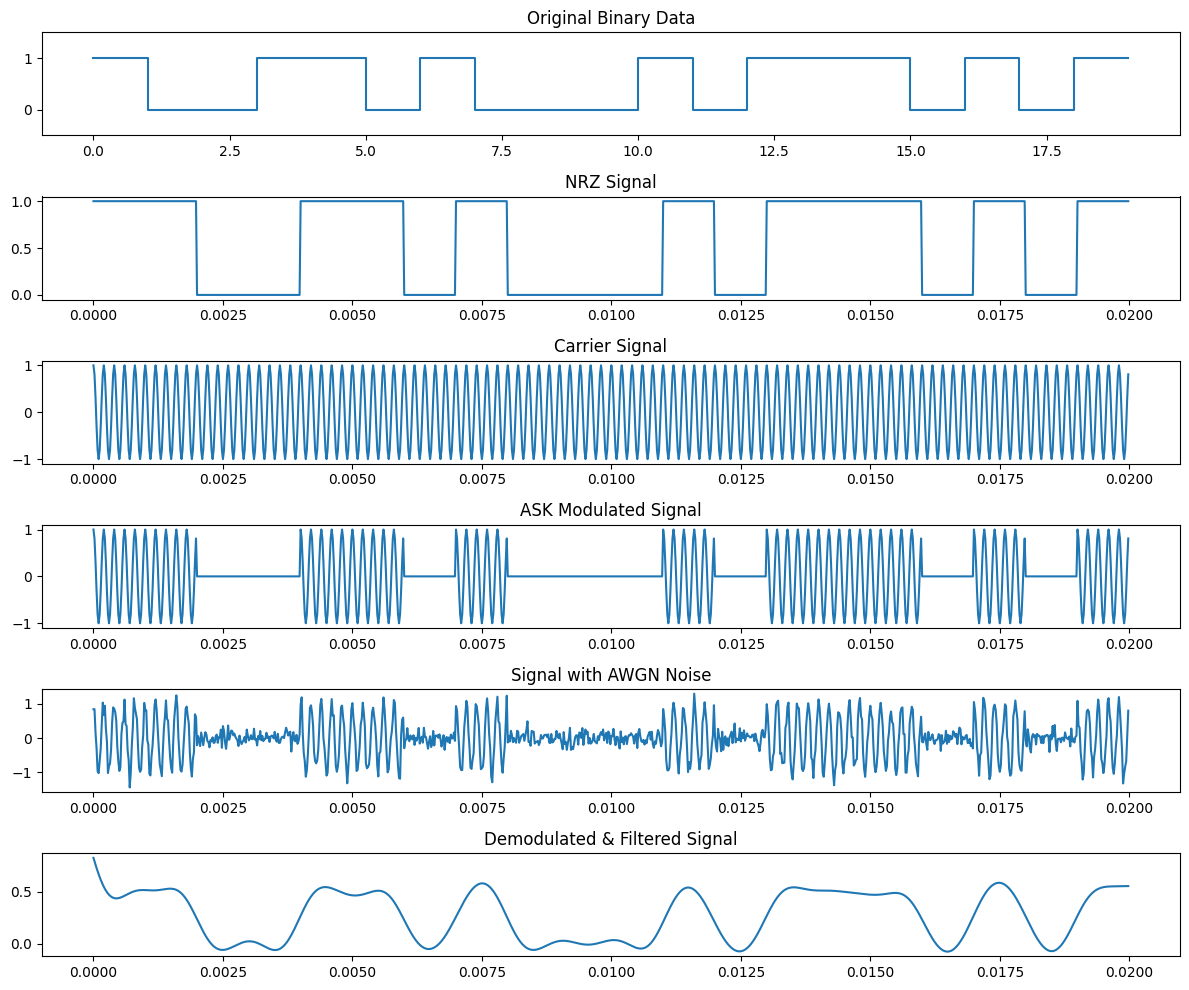

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# System Parameters
# -----------------------------
N = 20  # Number of bits
Rb = 1000  # Bit rate (bps)
Tb = 1 / Rb  # Bit duration
fc = 5000  # Carrier frequency (Hz)
fs = 50000  # Sampling frequency (Hz)
SNR_dB = 10  # Signal-to-noise ratio (dB)

samples_per_bit = int(fs / Rb)

# Generate Random Binary Data
# -----------------------------
data = np.random.randint(0, 2, N)

# Time Vector
# -----------------------------
t = np.arange(0, N * Tb, 1 / fs)

# NRZ Signal
# -----------------------------
nrz = np.repeat(data, samples_per_bit)

# Carrier Signal
# -----------------------------
carrier = np.cos(2 * np.pi * fc * t)

# ASK Modulation
# -----------------------------
ask_signal = nrz * carrier

# Add AWGN Noise
# -----------------------------
signal_power = np.mean(ask_signal**2)
SNR_linear = 10 ** (SNR_dB / 10)
noise_power = signal_power / SNR_linear

noise = np.sqrt(noise_power) * np.random.randn(len(ask_signal))
noisy_signal = ask_signal + noise

# Coherent Detection
# -----------------------------
demodulated = noisy_signal * carrier

# Low Pass Filter
# -----------------------------
cutoff = Rb
b, a = butter(5, cutoff / (fs / 2), btype="low")
filtered = filtfilt(b, a, demodulated)

# Threshold Detection
# -----------------------------
threshold = 0.25
recovered_bits = []

for i in range(N):
    idx = int(i * samples_per_bit + samples_per_bit / 2)
    if filtered[idx] > threshold:
        recovered_bits.append(1)
    else:
        recovered_bits.append(0)

recovered_bits = np.array(recovered_bits)

# BER Calculation
# -----------------------------
bit_errors = np.sum(data != recovered_bits)
BER = bit_errors / N

print("Original bits:   ", data)
print("Recovered bits:  ", recovered_bits)
print("Bit Error Rate:", BER)

# Plotting
# -----------------------------
plt.figure(figsize=(12, 10))

plt.subplot(6, 1, 1)
plt.step(range(N), data)
plt.title("Original Binary Data")
plt.ylim([-0.5, 1.5])

plt.subplot(6, 1, 2)
plt.plot(t, nrz)
plt.title("NRZ Signal")

plt.subplot(6, 1, 3)
plt.plot(t, carrier)
plt.title("Carrier Signal")

plt.subplot(6, 1, 4)
plt.plot(t, ask_signal)
plt.title("ASK Modulated Signal")

plt.subplot(6, 1, 5)
plt.plot(t, noisy_signal)
plt.title("Signal with AWGN Noise")

plt.subplot(6, 1, 6)
plt.plot(t, filtered)
plt.title("Demodulated & Filtered Signal")

plt.tight_layout()
plt.show()